In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import os, copy, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
)
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import timm
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    balanced_accuracy_score, f1_score, classification_report,
    recall_score, roc_auc_score, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from scipy.optimize import minimize_scalar
from scipy.special import log_softmax as scipy_log_softmax

print('Imports OK')


Imports OK


In [2]:
# ============================================================
# CELL 2 — DEVICE + REPRODUCIBILITY
# ============================================================
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    device = torch.device('cpu')
    print('WARNING: No GPU — training will be very slow')


GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# ============================================================
# CELL 3 — CONFIGURATION + PATH VERIFICATION
# ============================================================

# ── PATHS ─────────────────────────────────────────────────────────────────────
HAM_DIR      = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
ISIC_DIR     = '/kaggle/input/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification'
DERM7_DIR    = '/kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0'
FITZ_DIR     = '/kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder'
DERMNET_DIR  = '/kaggle/input/datasets/shubhamgoel27/dermnet'
AUGMENTED_DIR = '/kaggle/input/datasets/rohansuri214/dermascan-augmented'
PADUFES_DIR   = '/kaggle/input/datasets/hirantheboss/pad-uefs-20'

# ── PATH VERIFICATION ─────────────────────────────────────────────────────────
print('Path verification:')
path_status = {}
for label, path in [
    ('HAM10000',        HAM_DIR),
    ('ISIC 2019',       ISIC_DIR),
    ('Derm7pt',         DERM7_DIR),
    ('Fitzpatrick17k',  FITZ_DIR),
    ('Dermnet',         DERMNET_DIR),
    ('Augmented AK+DF', AUGMENTED_DIR),
    ('PAD-UFES-20',     PADUFES_DIR),
]:
    exists = os.path.exists(path)
    path_status[label] = exists
    print(f'  [{"OK " if exists else "MISSING"}] {label:18s} {path}')

assert path_status['HAM10000'], f'CRITICAL: HAM10000 not found at {HAM_DIR}'
assert path_status['Augmented AK+DF'], (
    f'CRITICAL: Augmented AK+DF dataset not found at {AUGMENTED_DIR}. '
    f'Complete Step 1 first — run dermascan_augmentation.ipynb and upload the zip.'
)

clinical_available = sum([
    path_status['Derm7pt'], path_status['Fitzpatrick17k'],
    path_status['Dermnet'], path_status['PAD-UFES-20'],
])
assert clinical_available >= 1, 'CRITICAL: No clinical datasets found'
print(f'\nClinical datasets available: {clinical_available}/4')

if not path_status['PAD-UFES-20']:
    print('WARNING: PAD-UFES-20 not found. Add it for best domain gap results.')
    print('  To find the path, run this in a cell:')
    print('  import os')
    print('  for r,d,f in os.walk("/kaggle/input"):')
    print('      for fi in f:')
    print('          if "metadata" in fi.lower() and "pad" in r.lower(): print(r)')

# ── MODEL ──────────────────────────────────────────────────────────────────────
MODEL_NAME   = 'efficientnet_b2'
IMG_SIZE     = 260
NUM_CLASSES  = 7
DROPOUT_RATE = 0.3
METADATA_DIM = 21
META_HIDDEN  = 64
META_OUT     = 32

# ── TRAINING ───────────────────────────────────────────────────────────────────
BATCH_SIZE   = 24

EPOCHS_S1    = 20

EPOCHS_S2    = 50
LR_S1        = 1e-3
LR_S2        = 1e-4
LR_MIN       = 1e-6
WARMUP       = 3
GRAD_CLIP    = 1.0
PATIENCE     = 14
FOCAL_GAMMA  = 2.0
LABEL_SMOOTHING = 0.02
MIXUP_ALPHA  = 0.1
WEIGHT_DECAY = 1e-4
CHECKPOINT_EVERY = 5


CLINICAL_DOMAIN_BOOST = 2.0

COMPOSITE_F1_WEIGHT     = 0.35   # 35% overall quality
COMPOSITE_CANCER_WEIGHT = 0.65   # 65% cancer recall (across all three)
COMPOSITE_MEL_WEIGHT    = 0.40   # within cancer recall block
COMPOSITE_BCC_WEIGHT    = 0.25
COMPOSITE_AK_WEIGHT     = 0.35

# ── CLASS DEFINITIONS ──────────────────────────────────────────────────────────
LABEL_MAP = {'nv':0,'mel':1,'bkl':2,'bcc':3,'akiec':4,'vasc':5,'df':6}
CLASS_NAMES = [
    'Melanocytic nevi',       # 0 — benign
    'Melanoma',               # 1 — CANCER
    'Benign keratosis',       # 2 — benign
    'Basal cell carcinoma',   # 3 — CANCER
    'Actinic keratoses',      # 4 — CANCER
    'Vascular lesions',       # 5 — benign
    'Dermatofibroma',         # 6 — benign
]
CANCER_IDX = [1, 3, 4]
BENIGN_IDX = [0, 2, 5, 6]
ISIC_MAP   = {'NV':0,'MEL':1,'BKL':2,'BCC':3,'AK':4,'VASC':5,'DF':6}

SEX_MAP  = {'male':0,'female':1,'unknown':2}
LOC_MAP  = {
    'back':0,'lower extremity':1,'trunk':2,'upper extremity':3,
    'abdomen':4,'face':5,'chest':6,'foot':7,'neck':8,
    'scalp':9,'hand':10,'ear':11,'genital':12,'acral':13,'unknown':14
}
DERM7_LOC_MAP = {
    'back':0,'lower limbs':1,'abdomen':4,'upper limbs':3,
    'chest':6,'head neck':5,'acral':13,'buttocks':2,'genital areas':12
}
DOMAIN_MAP = {'dermoscopic':0,'clinical':1}

print('='*70)
print(f'DermaScan v15 | {MODEL_NAME} @ {IMG_SIZE}x{IMG_SIZE}')
print(f'Stage1={EPOCHS_S1}ep | Stage2={EPOCHS_S2}ep | ClinBoost={CLINICAL_DOMAIN_BOOST}x')
print(f'Composite: {COMPOSITE_F1_WEIGHT}*F1 + {COMPOSITE_CANCER_WEIGHT}*(MEL={COMPOSITE_MEL_WEIGHT}/BCC={COMPOSITE_BCC_WEIGHT}/AK={COMPOSITE_AK_WEIGHT})')
print('='*70)


Path verification:
  [OK ] HAM10000           /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
  [OK ] ISIC 2019          /kaggle/input/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification
  [OK ] Derm7pt            /kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0
  [OK ] Fitzpatrick17k     /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder
  [OK ] Dermnet            /kaggle/input/datasets/shubhamgoel27/dermnet
  [OK ] Augmented AK+DF    /kaggle/input/datasets/rohansuri214/dermascan-augmented
  [OK ] PAD-UFES-20        /kaggle/input/datasets/hirantheboss/pad-uefs-20

Clinical datasets available: 4/4
DermaScan v15 | efficientnet_b2 @ 260x260
Stage1=20ep | Stage2=50ep | ClinBoost=2.0x
Composite: 0.35*F1 + 0.65*(MEL=0.4/BCC=0.25/AK=0.35)


In [ ]:
# ============================================================
# CELL 4 — CANONICAL PREPROCESSING + DOMAIN BRIDGE
# ============================================================

PREPROCESS_SPEC = {
    'input_size'             : IMG_SIZE,
    'resize_mode'            : 'squash',
    'channel_order'          : 'RGB',
    'normalize_mean'         : [0.485, 0.456, 0.406],
    'normalize_std'          : [0.229, 0.224, 0.225],
    'pixel_range_before_norm': [0.0, 1.0],
    'dtype'                  : 'float32',
}

class DermToClinicTransform:
    def __init__(self, p=0.5): self.p = p

    def __call__(self, img):
        if random.random() > self.p: return img
        if random.random() < 0.6:
            w,h  = img.size; scale = random.uniform(0.85,0.95)
            nw,nh = int(w*scale), int(h*scale)
            l,t  = (w-nw)//2, (h-nh)//2
            img  = TF.crop(img,t,l,nh,nw)
            img  = TF.resize(img,(h,w),interpolation=transforms.InterpolationMode.BILINEAR)
        if random.random() < 0.5:
            img = TF.adjust_contrast(img, random.uniform(0.6,0.90))
        if random.random() < 0.4:
            img = TF.gaussian_blur(img, kernel_size=3, sigma=random.uniform(0.4,1.2))
        if random.random() < 0.3:
            a = np.array(img,dtype=np.float32); hn,wn = a.shape[:2]
            cx,cy = random.randint(wn//5,4*wn//5), random.randint(hn//5,4*hn//5)
            rx,ry = random.randint(8,35), random.randint(6,25)
            Y,X = np.ogrid[:hn,:wn]
            mask = ((X-cx)**2/max(rx**2,1)+(Y-cy)**2/max(ry**2,1))<=1.0
            a[mask] = np.clip(a[mask]+random.uniform(40,90),0,255)
            img = Image.fromarray(a.astype(np.uint8))
        if random.random() < 0.25:
            a = np.array(img,dtype=np.float32); hn,wn = a.shape[:2]
            for _ in range(random.randint(2,8)):
                x0,y0 = random.randint(0,wn), random.randint(0,hn)
                ang = random.uniform(0,np.pi)
                ln  = random.randint(int(min(hn,wn)*0.15),int(min(hn,wn)*0.55))
                th  = random.randint(1,2); hc = random.randint(15,55)
                ca  = random.uniform(-25,25)
                for t_ in np.linspace(0,1,ln*4):
                    cv = np.sin(t_*np.pi)*ca
                    x  = int(x0+t_*ln*np.cos(ang)+cv); y = int(y0+t_*ln*np.sin(ang))
                    for dx in range(-th,th+1):
                        for dy in range(-th,th+1):
                            nx,ny = x+dx,y+dy
                            if 0<=nx<wn and 0<=ny<hn: a[ny,nx]=[hc]*3
            img = Image.fromarray(a.astype(np.uint8))
        return img

derm_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75,1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180), DermToClinicTransform(p=0.5),
    transforms.ColorJitter(0.25,0.25,0.25,0.1), transforms.RandomGrayscale(p=0.03),
    transforms.GaussianBlur(3,sigma=(0.1,1.5)), transforms.ToTensor(),
    transforms.Normalize(PREPROCESS_SPEC['normalize_mean'],PREPROCESS_SPEC['normalize_std']),
    transforms.RandomErasing(p=0.15),
])
clinical_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65,1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(0.4,0.4,0.35,0.15), transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(3,sigma=(0.1,2.0)),
    transforms.RandomAdjustSharpness(2,p=0.2), transforms.ToTensor(),
    transforms.Normalize(PREPROCESS_SPEC['normalize_mean'],PREPROCESS_SPEC['normalize_std']),
    transforms.RandomErasing(p=0.2),
])
ak_hard_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.50,0.85)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180), DermToClinicTransform(p=0.4),
    transforms.ColorJitter(0.5,0.5,0.4,0.2), transforms.RandomGrayscale(p=0.08),
    transforms.GaussianBlur(3,sigma=(0.1,2.5)),
    transforms.RandomAdjustSharpness(3,p=0.3), transforms.ToTensor(),
    transforms.Normalize(PREPROCESS_SPEC['normalize_mean'],PREPROCESS_SPEC['normalize_std']),
    transforms.RandomErasing(p=0.25),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(PREPROCESS_SPEC['normalize_mean'],PREPROCESS_SPEC['normalize_std']),
])

def preprocess_for_inference(pil_image):
    if pil_image.mode != 'RGB': pil_image = pil_image.convert('RGB')
    return val_transform(pil_image).unsqueeze(0)

_d = Image.fromarray(np.random.randint(50,200,(400,400,3),dtype=np.uint8))
assert preprocess_for_inference(_d).shape == (1,3,IMG_SIZE,IMG_SIZE)
assert derm_transform(_d).shape == (3,IMG_SIZE,IMG_SIZE)
print('All preprocessing transforms verified OK')


All preprocessing transforms verified OK


In [ ]:
# ============================================================
# CELL 5 — METADATA ENCODING
# ============================================================

def encode_metadata(age=None, sex=None, location=None, domain='clinical'):
    meta = np.zeros(METADATA_DIM, dtype=np.float32)
    meta[0] = float(np.clip(age/100.0,0,1)) if (age is not None and not (isinstance(age,float) and np.isnan(age))) else 0.5
    meta[1+SEX_MAP.get(str(sex).lower().strip() if sex else 'unknown',2)] = 1.0
    meta[4+LOC_MAP.get(str(location).lower().strip() if location else 'unknown',14)] = 1.0
    meta[19+DOMAIN_MAP.get(str(domain).lower().strip(),1)] = 1.0
    return torch.tensor(meta, dtype=torch.float32)

def encode_app_metadata(age_years=None, sex_str=None, location_str=None):
    return encode_metadata(age=age_years,sex=sex_str,location=location_str,domain='clinical').unsqueeze(0)

_m = encode_metadata(age=65,sex='male',location='back',domain='dermoscopic')
assert _m.shape==(METADATA_DIM,) and abs(_m[0].item()-0.65)<1e-4
assert _m[19].item()==1.0 and encode_metadata()[20].item()==1.0
print('Metadata encoding verified OK')


Metadata encoding verified OK


In [ ]:
# ============================================================
# CELL 6 — DATASET CLASSES
# ============================================================

class HAM10000WithMeta(Dataset):
    def __init__(self, df, image_dirs, transform=None):
        self.df=df.reset_index(drop=True); self.image_dirs=image_dirs; self.transform=transform
    def __len__(self): return len(self.df)
    def get_label(self,i): return LABEL_MAP[self.df.iloc[i]['dx']]
    def __getitem__(self,i):
        row=self.df.iloc[i]; label=LABEL_MAP[row['dx']]
        meta=encode_metadata(age=row.get('age'),sex=row.get('sex'),location=row.get('localization'),domain='dermoscopic')
        for d in self.image_dirs:
            p=os.path.join(d,f"{row['image_id']}.jpg")
            if os.path.exists(p):
                img=Image.open(p).convert('RGB')
                if self.transform: img=self.transform(img)
                return img,meta,label
        raise FileNotFoundError(f"{row['image_id']}.jpg not found")

class ISIC2019WithMeta(Dataset):
    def __init__(self,isic_dir,ham_dir,class_map,transform=None):
        self.transform=transform; self.default_meta=encode_metadata(domain='dermoscopic')
        ham_ids=set(pd.read_csv(os.path.join(ham_dir,'HAM10000_metadata.csv'))['image_id'].values)
        self.image_paths,self.labels=[],[]
        for folder,label_idx in class_map.items():
            path=os.path.join(isic_dir,folder)
            if not os.path.exists(path): continue
            for f in os.listdir(path):
                if f.lower().endswith(('.jpg','.jpeg','.png')) and os.path.splitext(f)[0] not in ham_ids:
                    self.image_paths.append(os.path.join(path,f)); self.labels.append(label_idx)
        print(f'  ISIC 2019 (after HAM dedup): {len(self.image_paths)}')
    def __len__(self): return len(self.image_paths)
    def get_label(self,i): return self.labels[i]
    def __getitem__(self,i):
        img=Image.open(self.image_paths[i]).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,self.default_meta,self.labels[i]

class Derm7ptDataset(Dataset):
    # val_fraction=0.25, StratifiedShuffleSplit
    def __init__(self,meta_csv,img_base,transform=None,use_clinical=True,val_fraction=0.25,seed=42):
        self.transform=transform
        domain='clinical' if use_clinical else 'dermoscopic'
        img_col='clinic' if use_clinical else 'derm'
        diag_map={
            'clark nevus':0,'reed or spitz nevus':0,'dermal nevus':0,'blue nevus':0,
            'congenital nevus':0,'combined nevus':0,'recurrent nevus':0,'lentigo':0,
            'melanoma':1,'melanoma (less than 0.76 mm)':1,'melanoma (in situ)':1,
            'melanoma (0.76 to 1.5 mm)':1,'melanoma (more than 1.5 mm)':1,'melanoma metastasis':1,
            'seborrheic keratosis':2,'basal cell carcinoma':3,'vascular lesion':5,'dermatofibroma':6,
        }
        df=pd.read_csv(meta_csv); all_items=[]
        for _,row in df.iterrows():
            diag=str(row['diagnosis']).lower().strip()
            if diag not in diag_map: continue
            img_path=os.path.join(img_base,str(row[img_col]))
            if not os.path.exists(img_path): continue
            sex=str(row.get('sex','unknown')).lower().strip()
            loc_raw=str(row.get('location','unknown')).lower().strip()
            loc_idx=DERM7_LOC_MAP.get(loc_raw,LOC_MAP['unknown'])
            loc_name=next((k for k,v in LOC_MAP.items() if v==loc_idx),'unknown')
            meta=encode_metadata(age=None,sex=sex,location=loc_name,domain=domain)
            all_items.append({'path':img_path,'label':diag_map[diag],'meta':meta})

        # StratifiedShuffleSplit ensures every class in val
        if use_clinical and len(all_items) >= 10:
            labels_arr = np.array([it['label'] for it in all_items])
            # Only stratify on classes that have enough samples
            from collections import Counter
            counts = Counter(labels_arr)
            # Filter to items whose class has at least 2 samples for stratification
            valid_idx = [i for i,it in enumerate(all_items) if counts[it['label']] >= 2]
            if len(valid_idx) > 20:
                sub_items  = [all_items[i] for i in valid_idx]
                sub_labels = labels_arr[[i for i in valid_idx]]
                sss = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
                tr_i, va_i = next(sss.split(np.zeros(len(sub_labels)), sub_labels))
                val_set  = set(valid_idx[i] for i in va_i)
                self.items     = [all_items[i] for i in range(len(all_items)) if i not in val_set]
                self.val_items = [all_items[i] for i in val_set]
            else:
                # Fallback to random if too few samples for stratification
                np.random.seed(seed)
                n_val = max(20, int(val_fraction*len(all_items)))
                val_idx = set(np.random.choice(len(all_items), n_val, replace=False))
                self.items     = [all_items[i] for i in range(len(all_items)) if i not in val_idx]
                self.val_items = [all_items[i] for i in val_idx]
        else:
            self.items = all_items; self.val_items = []

        print(f'  Derm7pt ({domain}): {len(self.items)} train / {len(self.val_items)} val')

    def __len__(self): return len(self.items)
    def get_label(self,i): return self.items[i]['label']
    def __getitem__(self,i):
        item=self.items[i]; img=Image.open(item['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,item['meta'],item['label']

class Derm7ptValDataset(Dataset):
    def __init__(self,derm7_dataset,transform=None):
        self.items=derm7_dataset.val_items; self.transform=transform
    def __len__(self): return len(self.items)
    def get_label(self,i): return self.items[i]['label']
    def __getitem__(self,i):
        item=self.items[i]; img=Image.open(item['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,item['meta'],item['label']

class Fitzpatrick17kDataset(Dataset):
    def __init__(self,csv_path,img_dir,transform=None):
        self.transform=transform
        df=pd.read_csv(csv_path)
        label_map={}
        for lbl in df['label'].unique():
            ll=str(lbl).lower()
            if 'melanoma' in ll: label_map[lbl]=1
            elif 'basal cell' in ll: label_map[lbl]=3
            elif 'actinic' in ll or 'porokeratosis' in ll: label_map[lbl]=4
            elif 'seborrheic keratosis' in ll: label_map[lbl]=2
            elif 'dermatofibroma' in ll: label_map[lbl]=6
            elif 'pyogenic granuloma' in ll or 'hemangioma' in ll: label_map[lbl]=5
        img_files=set(os.listdir(img_dir))
        self.items=[]
        for _,row in df.iterrows():
            lbl=row['label']
            if lbl not in label_map: continue
            img_name=f"{row['md5hash']}.jpg"
            if img_name not in img_files: continue
            self.items.append({'path':os.path.join(img_dir,img_name),'label':label_map[lbl],'meta':encode_metadata(domain='clinical')})
        print(f'  Fitzpatrick17k: {len(self.items)} (clinical)')
    def __len__(self): return len(self.items)
    def get_label(self,i): return self.items[i]['label']
    def __getitem__(self,i):
        item=self.items[i]; img=Image.open(item['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,item['meta'],item['label']

class DermnetDataset(Dataset):
    def __init__(self,base_dir,transform=None):
        self.transform=transform
        safe_folders={'Seborrheic Keratoses and other Benign Tumors':2,'Vascular Tumors':5}
        self.items=[]
        for folder,label in safe_folders.items():
            for split in ['train','test']:
                path=os.path.join(base_dir,split,folder)
                if not os.path.exists(path): continue
                for f in os.listdir(path):
                    if f.lower().endswith(('.jpg','.jpeg','.png')):
                        self.items.append({'path':os.path.join(path,f),'label':label,'meta':encode_metadata(domain='clinical')})
        print(f'  Dermnet: {len(self.items)} (clinical)')
    def __len__(self): return len(self.items)
    def get_label(self,i): return self.items[i]['label']
    def __getitem__(self,i):
        item=self.items[i]; img=Image.open(item['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,item['meta'],item['label']

class AKHardAugDataset(Dataset):
    def __init__(self,dataset,base_transform,hard_transform,ak_class=4):
        self.dataset=dataset; self.base_transform=base_transform
        self.hard_transform=hard_transform; self.ak_class=ak_class
    def __len__(self): return len(self.dataset)
    def get_label(self,i): return self.dataset.get_label(i)
    def __getitem__(self,i):
        orig=self.dataset.transform; self.dataset.transform=None
        item=self.dataset[i]; self.dataset.transform=orig
        img,meta,label=item
        img=self.hard_transform(img) if label==self.ak_class else (self.base_transform(img) if self.base_transform else img)
        return img,meta,label

# Loads pre-generated offline augmented AK and DF images
class AugmentedMinorityDataset(Dataset):
    """
    Loads the offline-augmented AK and DF images generated by Step 1
    (dermascan_augmentation.ipynb). These are already augmented JPEG files
    that provide extra diversity beyond the 1,453 original AK and 323 DF images.

    Uses derm_transform (not ak_hard_transform) at training time because
    the images were already strongly augmented during generation.
    Adding another layer of augmentation increases variety further.
    domain=dermoscopic because source images were HAM10000/ISIC dermoscopic.
    """
    def __init__(self,base_dir,transform=None):
        self.transform=transform
        info_path=os.path.join(base_dir,'dataset_info.json')
        if os.path.exists(info_path):
            with open(info_path) as f: info=json.load(f)
            print(f'  Augmented dataset:')
            for cls,d in info['classes'].items():
                print(f'    {d["class_name"]}: {d["n_total"]} images (from {d["n_originals"]} originals)')
        label_map={'ak':4,'df':6}
        self.items=[]
        for folder_name,label in label_map.items():
            folder=os.path.join(base_dir,folder_name)
            if not os.path.exists(folder):
                print(f'  WARNING: {folder} not found'); continue
            count=0
            for f in os.listdir(folder):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.items.append({'path':os.path.join(folder,f),'label':label,'meta':encode_metadata(domain='dermoscopic')})
                    count+=1
            print(f'  Augmented {CLASS_NAMES[label]}: {count} images')
    def __len__(self): return len(self.items)
    def get_label(self,i): return self.items[i]['label']
    def __getitem__(self,i):
        item=self.items[i]; img=Image.open(item['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,item['meta'],item['label']

# PAD-UFES-20 smartphone clinical images
class PADUFES20Dataset(Dataset):
    """
    PAD-UFES-20 — 2,298 smartphone clinical photos with patient metadata.
    Most deployment-relevant dataset: real phone camera images matching the app.
    Handles split folder layout (PAD-UFES-20_images_part_1/2/3).
    SCC dropped — no matching class in current 7-class scheme.
    """
    def __init__(self,csv_path,image_dirs,transform=None):
        self.transform=transform
        diag_map={'MEL':1,'BCC':3,'ACK':4,'NEV':0,'SEK':2}
        pad_loc={'FACE':'face','NOSE':'face','LIP':'face','NECK':'neck','CHEST':'chest',
                 'BACK':'back','ARM':'upper extremity','FOREARM':'upper extremity',
                 'HAND':'hand','ABDOMEN':'abdomen','THIGH':'lower extremity',
                 'EAR':'ear','SCALP':'scalp','FOOT':'foot'}
        # Build image index across all part folders
        img_index={}
        dirs = image_dirs if isinstance(image_dirs,list) else [image_dirs]
        for d in dirs:
            if not os.path.exists(d): continue
            for f in os.listdir(d):
                if f.lower().endswith(('.png','.jpg','.jpeg')):
                    img_index[f]=os.path.join(d,f)
        print(f'  PAD-UFES-20: indexed {len(img_index)} images across {len(dirs)} folders')
        df=pd.read_csv(csv_path); self.items=[]; skipped=0
        for _,row in df.iterrows():
            diag=str(row.get('diagnostic','')).strip().upper()
            if diag not in diag_map: skipped+=1; continue
            img_id=str(row['img_id']).strip()
            img_path=None
            if img_id in img_index: img_path=img_index[img_id]
            else:
                for ext in ['.png','.jpg','.jpeg']:
                    if img_id+ext in img_index: img_path=img_index[img_id+ext]; break
            if img_path is None: skipped+=1; continue
            try: age=float(row['age']) if pd.notna(row.get('age')) else None
            except: age=None
            sex=str(row.get('gender','unknown')).strip().lower()
            sex=sex if sex in ('male','female') else 'unknown'
            loc=pad_loc.get(str(row.get('region','unknown')).strip().upper(),'unknown')
            self.items.append({'path':img_path,'label':diag_map[diag],
                                'meta':encode_metadata(age=age,sex=sex,location=loc,domain='clinical')})
        print(f'  PAD-UFES-20: {len(self.items)} loaded | {skipped} skipped (SCC/missing)')
        counts={}
        for it in self.items: counts[it['label']]=counts.get(it['label'],0)+1
        for ci,n in sorted(counts.items()):
            tag=' (CANCER)' if ci in CANCER_IDX else ''
            print(f'    [{ci}] {CLASS_NAMES[ci]}: {n}{tag}')
    def __len__(self): return len(self.items)
    def get_label(self,i): return self.items[i]['label']
    def __getitem__(self,i):
        item=self.items[i]; img=Image.open(item['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,item['meta'],item['label']

print('Dataset classes defined OK')


Dataset classes defined OK


In [ ]:
# ============================================================
# CELL 7 — LOAD DATASETS + BUILD DATALOADERS
# ============================================================

print('='*70); print('LOADING DATASETS'); print('='*70)

CSV_PATH   = os.path.join(HAM_DIR,'HAM10000_metadata.csv')
IMAGE_DIRS = [os.path.join(HAM_DIR,'HAM10000_images_part_1'),
              os.path.join(HAM_DIR,'HAM10000_images_part_2')]
full_meta  = pd.read_csv(CSV_PATH)
print(f'HAM10000: {len(full_meta)} total images')

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tv_idx,te_idx = next(gss_test.split(full_meta, groups=full_meta['lesion_id']))
train_val_df,test_df = full_meta.iloc[tv_idx], full_meta.iloc[te_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx,va_idx = next(gss_val.split(train_val_df, groups=train_val_df['lesion_id']))
train_df,val_df = train_val_df.iloc[tr_idx], train_val_df.iloc[va_idx]

assert len(set(train_df['lesion_id'])&set(val_df['lesion_id']))==0
assert len(set(train_df['lesion_id'])&set(test_df['lesion_id']))==0
assert len(set(val_df['lesion_id'])&set(test_df['lesion_id']))==0
print(f'Split: train={len(train_df)} | val={len(val_df)} | test={len(test_df)} — no leakage')

ham_train=HAM10000WithMeta(train_df,IMAGE_DIRS,transform=derm_transform)
ham_val  =HAM10000WithMeta(val_df,  IMAGE_DIRS,transform=val_transform)
ham_test =HAM10000WithMeta(test_df, IMAGE_DIRS,transform=val_transform)

isic_train=derm7_clinical=derm7_derm=derm7_clin_val=None
fitz_train=dermnet_train=aug_minority=padufes_train=None

# ISIC 2019
if path_status.get('ISIC 2019') and os.path.exists(os.path.join(ISIC_DIR,'MEL')):
    _isic=ISIC2019WithMeta(ISIC_DIR,HAM_DIR,ISIC_MAP,transform=None)
    isic_train=AKHardAugDataset(_isic,base_transform=derm_transform,hard_transform=ak_hard_transform)

# Derm7pt
if path_status.get('Derm7pt'):
    d7csv=os.path.join(DERM7_DIR,'meta','meta.csv'); d7imgs=os.path.join(DERM7_DIR,'images')
    if os.path.exists(d7csv):
        _d7c=Derm7ptDataset(d7csv,d7imgs,transform=clinical_transform,use_clinical=True)
        derm7_clin_val=Derm7ptValDataset(_d7c,transform=val_transform)
        derm7_clinical=_d7c
        derm7_derm=Derm7ptDataset(d7csv,d7imgs,transform=derm_transform,use_clinical=False)

# Fitzpatrick17k
if path_status.get('Fitzpatrick17k'):
    fc=os.path.join(FITZ_DIR,'fitzpatrick17k (1).csv'); fi=os.path.join(FITZ_DIR,'background removed')
    if os.path.exists(fc): fitz_train=Fitzpatrick17kDataset(fc,fi,transform=clinical_transform)

# Dermnet
if path_status.get('Dermnet') and os.path.exists(os.path.join(DERMNET_DIR,'train')):
    dermnet_train=DermnetDataset(DERMNET_DIR,transform=clinical_transform)

# Augmented minority (AK + DF)
if path_status.get('Augmented AK+DF') and os.path.exists(AUGMENTED_DIR):
    aug_minority=AugmentedMinorityDataset(AUGMENTED_DIR,transform=derm_transform)
    print(f'  Augmented minorities loaded: {len(aug_minority)} images')

# PAD-UFES-20
if path_status.get('PAD-UFES-20'):
    pad_csv=os.path.join(PADUFES_DIR,'PAD-UFES-20_metadata.csv')
    pad_imgs=[]
    for i in range(1,5):
        d=os.path.join(PADUFES_DIR,f'PAD-UFES-20_images_part_{i}')
        if os.path.exists(d): pad_imgs.append(d)
    if not pad_imgs:
        single=os.path.join(PADUFES_DIR,'images')
        if os.path.exists(single): pad_imgs=[single]
    if os.path.exists(pad_csv) and pad_imgs:
        padufes_train=PADUFES20Dataset(pad_csv,pad_imgs,transform=clinical_transform)

# Combine
train_parts=[ham_train]
for ds in [isic_train,derm7_clinical,derm7_derm,fitz_train,dermnet_train,aug_minority,padufes_train]:
    if ds: train_parts.append(ds)

train_dataset=ConcatDataset(train_parts) if len(train_parts)>1 else train_parts[0]

# Clinical dataset identification using id()
clinical_dataset_ids={id(d) for d in [derm7_clinical,fitz_train,dermnet_train,padufes_train] if d is not None}
clinical_indices=set()
offset=0
for ds in train_parts:
    if id(ds) in clinical_dataset_ids:
        clinical_indices.update(range(offset,offset+len(ds)))
        print(f'  Clinical match: [{offset},{offset+len(ds)}) size={len(ds)}')
    offset+=len(ds)

# PAD adds ~2k more clinical samples
assert len(clinical_indices)>=2000, (
    f'CRITICAL: only {len(clinical_indices)} clinical samples. '
    f'Expected >=2000 with PAD-UFES-20. Check paths for PAD and clinical datasets.'
)
print(f'Total clinical indices for boost: {len(clinical_indices)}')

# Build sampler
def get_all_labels(parts):
    labels=[]
    for ds in parts: labels.extend([ds.get_label(i) for i in range(len(ds))])
    return np.array(labels)

print('Building WeightedRandomSampler with clinical boost...')
all_labels=get_all_labels(train_parts)
cc=np.bincount(all_labels,minlength=NUM_CLASSES); cc[cc==0]=1
sample_weights=torch.from_numpy((1.0/cc.astype(float))[all_labels]).double()

# Apply boost
for idx in clinical_indices: sample_weights[idx]*=CLINICAL_DOMAIN_BOOST
print(f'Clinical boost ({CLINICAL_DOMAIN_BOOST}x) applied to {len(clinical_indices)} samples')

sampler=WeightedRandomSampler(sample_weights,len(sample_weights),replacement=True)

print('\nClass distribution:')
for i,name in enumerate(CLASS_NAMES):
    tag=' <- CANCER' if i in CANCER_IDX else ''
    print(f'  [{i}] {name}: {cc[i]:>5}{tag}')

n_clin=sum(len(ds) for ds in [derm7_clinical,fitz_train,dermnet_train,padufes_train] if ds)
n_derm=len(train_dataset)-n_clin
eff_clin_pct=(n_clin*CLINICAL_DOMAIN_BOOST)/(n_derm+n_clin*CLINICAL_DOMAIN_BOOST)*100
print(f'\nTotal: {len(train_dataset)} train | {len(ham_val)} dermoscopic-val | {len(ham_test)} test')
if derm7_clin_val: print(f'       {len(derm7_clin_val)} clinical-val (Derm7pt, stratified)')
print(f'Raw: Dermoscopic={n_derm} ({100*n_derm/len(train_dataset):.0f}%) | Clinical={n_clin} ({100*n_clin/len(train_dataset):.0f}%)')
print(f'Effective after {CLINICAL_DOMAIN_BOOST}x boost: clinical ~{eff_clin_pct:.0f}%')

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,sampler=sampler,num_workers=2,pin_memory=True)
val_loader  =DataLoader(ham_val, batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
test_loader =DataLoader(ham_test,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
clin_val_loader=None
if derm7_clin_val and len(derm7_clin_val)>0:
    clin_val_loader=DataLoader(derm7_clin_val,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
    print(f'Clinical-val loader ready: {len(derm7_clin_val)} images (stratified split)')


LOADING DATASETS
HAM10000: 10015 total images
Split: train=6817 | val=1174 | test=2024 — no leakage
  ISIC 2019 (after HAM dedup): 14885
  Derm7pt (clinical): 740 train / 247 val
  Derm7pt (dermoscopic): 987 train / 0 val
  Fitzpatrick17k: 1843 (clinical)
  Dermnet: 2317 (clinical)
  Augmented dataset:
    Actinic keratoses: 2998 images (from 1064 originals)
    Dermatofibroma: 1500 images (from 239 originals)
  Augmented Actinic keratoses: 2998 images
  Augmented Dermatofibroma: 1500 images
  Augmented minorities loaded: 4498 images
  PAD-UFES-20: indexed 2298 images across 3 folders
  PAD-UFES-20: 2106 loaded | 192 skipped (SCC/missing)
    [0] Melanocytic nevi: 244
    [1] Melanoma: 52 (CANCER)
    [2] Benign keratosis: 235
    [3] Basal cell carcinoma: 845 (CANCER)
    [4] Actinic keratoses: 730 (CANCER)
  Clinical match: [21702,22442) size=740
  Clinical match: [23429,25272) size=1843
  Clinical match: [25272,27589) size=2317
  Clinical match: [32087,34193) size=2106
Total clinica

In [ ]:
# ============================================================
# CELL 8 — MODEL ARCHITECTURE 
# ============================================================

class SkinCancerModelV15(nn.Module):
    def __init__(self,model_name=MODEL_NAME,num_classes=NUM_CLASSES,
                 meta_dim=METADATA_DIM,meta_hidden=META_HIDDEN,meta_out=META_OUT,drop_rate=DROPOUT_RATE):
        super().__init__()
        self.backbone=timm.create_model(model_name,pretrained=True,num_classes=0,drop_rate=drop_rate)
        backbone_out=self.backbone.num_features
        self.meta_mlp=nn.Sequential(
            nn.Linear(meta_dim,meta_hidden),nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(meta_hidden,meta_out),nn.ReLU())
        self.classifier=nn.Sequential(nn.Dropout(drop_rate),nn.Linear(backbone_out+meta_out,num_classes))
    def forward(self,image,metadata):
        return self.classifier(torch.cat([self.backbone(image),self.meta_mlp(metadata)],dim=1))

_t=SkinCancerModelV15().to(device)
_i=torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(device)
_m=encode_metadata().unsqueeze(0).expand(2,-1).to(device)
assert _t(_i,_m).shape==(2,NUM_CLASSES)
print(f'Model: {MODEL_NAME} | Params: {sum(p.numel() for p in _t.parameters()):,}')
del _t,_i,_m


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Model: efficientnet_b2 | Params: 7,714,569


In [ ]:
# ============================================================
# CELL 9 — LOSS FUNCTIONS 
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self,gamma=2.0,label_smoothing=0.0):
        super().__init__(); self.gamma=gamma; self.ls=label_smoothing
    def forward(self,logits,targets):
        ce=F.cross_entropy(logits,targets,reduction='none',label_smoothing=self.ls)
        return ((1-torch.exp(-ce))**self.gamma*ce).mean()

def mixup_focal_loss(logits,ya,yb,lam,gamma=2.0,ls=0.02):
    ce_a=F.cross_entropy(logits,ya,reduction='none',label_smoothing=ls)
    ce_b=F.cross_entropy(logits,yb,reduction='none',label_smoothing=ls)
    focal_a=(1-torch.exp(-ce_a))**gamma*ce_a
    focal_b=(1-torch.exp(-ce_b))**gamma*ce_b
    return (lam*focal_a+(1-lam)*focal_b).mean()

def mixup_images_only(x,y,alpha):
    if alpha<=0: return x,y,y,1.0
    lam=np.random.beta(alpha,alpha)
    idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx],y,y[idx],lam

print('Loss functions defined OK')


Loss functions defined OK


In [ ]:
# ============================================================
# CELL 10 — TRAIN / VALIDATE LOOPS 
# ============================================================

def train_epoch(model,loader,criterion,optimizer,scheduler,device,use_mixup=True,step_per_batch=False):
    model.train()
    for m in model.backbone.modules():
        if isinstance(m,nn.BatchNorm2d) and not m.weight.requires_grad: m.eval()
    loss_sum,preds_all,labels_all=0.0,[],[]
    for images,meta,labels in tqdm(loader,desc='Train',leave=False):
        images=images.to(device); meta=meta.to(device); labels=labels.squeeze().long().to(device)
        optimizer.zero_grad()
        if use_mixup and MIXUP_ALPHA>0:
            mx,ya,yb,lam=mixup_images_only(images,labels,MIXUP_ALPHA)
            loss=mixup_focal_loss(model(mx,meta),ya,yb,lam,FOCAL_GAMMA,LABEL_SMOOTHING)
        else:
            loss=criterion(model(images,meta),labels)
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); optimizer.step()
        if step_per_batch and scheduler: scheduler.step()
        loss_sum+=loss.item()
        with torch.no_grad(): _,pred=model(images,meta).max(1)
        preds_all.extend(pred.cpu().numpy()); labels_all.extend(labels.cpu().numpy())
    p,l=np.array(preds_all),np.array(labels_all)
    return {'loss':loss_sum/len(loader),'macro_f1':f1_score(l,p,average='macro',zero_division=0),'bal_acc':balanced_accuracy_score(l,p)}

def validate(model,loader,criterion,device):
    model.eval(); loss_sum=0.0; preds_all,labels_all,probs_all,logits_all=[],[],[],[]
    with torch.no_grad():
        for images,meta,labels in tqdm(loader,desc='Val',leave=False):
            images=images.to(device); meta=meta.to(device); labels=labels.squeeze().long().to(device)
            logits=model(images,meta); loss_sum+=criterion(logits,labels).item()
            probs=F.softmax(logits,dim=1)
            preds_all.extend(probs.argmax(dim=1).cpu().numpy()); labels_all.extend(labels.cpu().numpy())
            probs_all.append(probs.cpu().numpy()); logits_all.append(logits.cpu().numpy())
    p,l,pr,lg=np.array(preds_all),np.array(labels_all),np.vstack(probs_all),np.vstack(logits_all)
    rcl=recall_score(l,p,average=None,labels=list(range(NUM_CLASSES)),zero_division=0)
    return {'loss':loss_sum/len(loader),'macro_f1':f1_score(l,p,average='macro',zero_division=0),
            'bal_acc':balanced_accuracy_score(l,p),'per_class_recall':rcl,
            'predictions':p,'labels':l,'probabilities':pr,'logits':lg}

print('Train/validate loops defined OK')


Train/validate loops defined OK


In [ ]:
# ============================================================
# CELL 11 — TWO-STAGE TRAINING
# ============================================================

print('='*70); print('BUILDING MODEL'); print('='*70)

model=SkinCancerModelV15().to(device)
criterion=FocalLoss(gamma=FOCAL_GAMMA,label_smoothing=LABEL_SMOOTHING)

# ── STAGE 1: Warm up head + meta MLP + conv_head ────────────────────────────
print(f'\nSTAGE 1: Head warm-up ({EPOCHS_S1} epochs)')
for p in model.backbone.parameters(): p.requires_grad=False
for p in model.meta_mlp.parameters():  p.requires_grad=True
for p in model.classifier.parameters(): p.requires_grad=True
for p in model.backbone.conv_head.parameters(): p.requires_grad=True
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Trainable: {trainable:,} (head + meta MLP + conv_head)')

opt1=optim.AdamW([p for p in model.parameters() if p.requires_grad],lr=LR_S1,weight_decay=WEIGHT_DECAY)
best_s1=0.0
for ep in range(EPOCHS_S1):
    lr=LR_S1*min((ep+1)/max(WARMUP,1),1.0)
    for pg in opt1.param_groups: pg['lr']=lr
    tm=train_epoch(model,train_loader,criterion,opt1,scheduler=None,device=device,use_mixup=False)
    vm=validate(model,val_loader,criterion,device)
    mel=vm['per_class_recall'][1]; bcc=vm['per_class_recall'][3]; ak=vm['per_class_recall'][4]
    cancer_comp=COMPOSITE_MEL_WEIGHT*mel+COMPOSITE_BCC_WEIGHT*bcc+COMPOSITE_AK_WEIGHT*ak
    s1_comp=COMPOSITE_F1_WEIGHT*vm['macro_f1']+COMPOSITE_CANCER_WEIGHT*cancer_comp
    print(f'  S1 E{ep+1:02d} | lr={lr:.4f} | Train={tm["macro_f1"]:.4f} | Val={vm["macro_f1"]:.4f} | '
          f'Mel={mel:.4f} BCC={bcc:.4f} AK={ak:.4f} | Comp={s1_comp:.4f}',end='')
    if s1_comp>best_s1:
        best_s1=s1_comp; torch.save(model.state_dict(),'v15_s1.pth'); print(' ** BEST',end='')
    print()

model.load_state_dict(torch.load('v15_s1.pth',weights_only=True))
print(f'  Stage 1 done. Best composite: {best_s1:.4f}')

# ── STAGE 2: Full fine-tune ─────────────────────────────────────────────────
print(f'\nSTAGE 2: Full fine-tune ({EPOCHS_S2} epochs, OneCycleLR)')
for p in model.parameters(): p.requires_grad=True
bn_count=0
for m in model.backbone.modules():
    if isinstance(m,nn.BatchNorm2d):
        m.eval(); m.weight.requires_grad=False; m.bias.requires_grad=False; bn_count+=1
print(f'  Frozen {bn_count} BatchNorm layers')

pg=[]
sp=[p for p in model.backbone.conv_stem.parameters() if p.requires_grad]
if sp: pg.append({'params':sp,'lr':LR_S2*0.01})
for i,blk in enumerate(model.backbone.blocks):
    bp=[p for p in blk.parameters() if p.requires_grad]
    if bp: pg.append({'params':bp,'lr':LR_S2*(0.1 if i<=2 else 0.3 if i<=4 else 0.5)})
hp=[p for p in model.backbone.conv_head.parameters() if p.requires_grad]
if hp: pg.append({'params':hp,'lr':LR_S2*0.5})
pg.append({'params':list(model.meta_mlp.parameters()),'lr':LR_S2})
pg.append({'params':list(model.classifier.parameters()),'lr':LR_S2})

opt2=optim.AdamW(pg,weight_decay=WEIGHT_DECAY)
sched=optim.lr_scheduler.OneCycleLR(
    opt2,max_lr=[g['lr'] for g in opt2.param_groups],
    epochs=EPOCHS_S2,steps_per_epoch=len(train_loader),
    pct_start=0.1,anneal_strategy='cos',div_factor=10.0,final_div_factor=1e4)

best_comp,patience_count=0.0,0; comp_history=[]

for ep in range(EPOCHS_S2):
    cur_lr=opt2.param_groups[-1]['lr']
    tm=train_epoch(model,train_loader,criterion,opt2,scheduler=sched,device=device,
                   use_mixup=True,step_per_batch=True)
    vm=validate(model,val_loader,criterion,device)
    mel=vm['per_class_recall'][1]; bcc=vm['per_class_recall'][3]; ak=vm['per_class_recall'][4]
    gap=tm['macro_f1']-vm['macro_f1']
    cancer_comp=COMPOSITE_MEL_WEIGHT*mel+COMPOSITE_BCC_WEIGHT*bcc+COMPOSITE_AK_WEIGHT*ak
    comp=COMPOSITE_F1_WEIGHT*vm['macro_f1']+COMPOSITE_CANCER_WEIGHT*cancer_comp
    comp_history.append(comp); rolling_comp=np.mean(comp_history[-3:])
    print(f'  S2 E{ep+1:02d}/{EPOCHS_S2} | lr={cur_lr:.6f} | Train={tm["macro_f1"]:.4f} | '
          f'Val={vm["macro_f1"]:.4f} | Gap={gap:.3f} | '
          f'Mel={mel:.4f} BCC={bcc:.4f} AK={ak:.4f} | Roll={rolling_comp:.4f}',end='')
    if rolling_comp>best_comp:
        best_comp=rolling_comp; torch.save(model.state_dict(),'v15_s2.pth')
        print(' ** BEST',end=''); patience_count=0
    else: patience_count+=1
    print()
    if (ep+1)%CHECKPOINT_EVERY==0:
        torch.save(model.state_dict(),f'v15_s2_epoch{ep+1:02d}.pth')
        print(f'    [checkpoint saved: v15_s2_epoch{ep+1:02d}.pth]')
    if patience_count>=PATIENCE: print(f'  Early stopping at epoch {ep+1}'); break
    if (ep+1)%10==0:
        print(classification_report(vm['labels'],vm['predictions'],target_names=CLASS_NAMES,digits=4))

model.load_state_dict(torch.load('v15_s2.pth',weights_only=True))
print(f'Stage 2 done. Best rolling composite: {best_comp:.4f}')
print(f'(= {COMPOSITE_F1_WEIGHT}*F1 + {COMPOSITE_CANCER_WEIGHT}*(MEL={COMPOSITE_MEL_WEIGHT}/BCC={COMPOSITE_BCC_WEIGHT}/AK={COMPOSITE_AK_WEIGHT}))')


BUILDING MODEL

STAGE 1: Head warm-up (20 epochs)
  Trainable: 509,191 (head + meta MLP + conv_head)


  S1 E01 | lr=0.0003 | Train=0.5163 | Val=0.3360 | Mel=0.3190 BCC=0.5000 AK=0.0000 | Comp=0.2818 ** BEST


  S1 E02 | lr=0.0007 | Train=0.5876 | Val=0.3569 | Mel=0.1293 BCC=0.4423 AK=0.0500 | Comp=0.2418


  S1 E03 | lr=0.0010 | Train=0.5989 | Val=0.4401 | Mel=0.4483 BCC=0.6538 AK=0.2250 | Comp=0.4280 ** BEST


  S1 E04 | lr=0.0010 | Train=0.6152 | Val=0.4107 | Mel=0.4138 BCC=0.6731 AK=0.1500 | Comp=0.3948


...

  S2 E46/50 | lr=0.000003 | Train=0.9649 | Val=0.7903 | Gap=0.175 | Mel=0.5345 BCC=0.7308 AK=0.8500 | Roll=0.7332


  S2 E47/50 | lr=0.000002 | Train=0.9635 | Val=0.7939 | Gap=0.170 | Mel=0.5517 BCC=0.7692 AK=0.8750 | Roll=0.7366


  S2 E48/50 | lr=0.000001 | Train=0.9646 | Val=0.7994 | Gap=0.165 | Mel=0.5603 BCC=0.7692 AK=0.8750 | Roll=0.7409


  S2 E49/50 | lr=0.000000 | Train=0.9635 | Val=0.7992 | Gap=0.164 | Mel=0.5517 BCC=0.7692 AK=0.8750 | Roll=0.7474 ** BEST


  S2 E50/50 | lr=0.000000 | Train=0.9639 | Val=0.7982 | Gap=0.166 | Mel=0.5431 BCC=0.7692 AK=0.8750 | Roll=0.7471
    [checkpoint saved: v15_s2_epoch50.pth]
                      precision    recall  f1-score   support

    Melanocytic nevi     0.9321    0.9537    0.9427       820
            Melanoma     0.5780    0.5431    0.5600       116
    Benign keratosis     0.7059    0.5854    0.6400       123
Basal cell carcinoma     0.7143    0.7692    0.7407        52
   Actinic keratoses     0.8537    0.8750    0.8642        40
    Vascular lesions     0.7857    1.0000    0.8800        11
      Dermatofibroma     0.9231    1.0000    0.9600        12

            accuracy                         0.8646      1174
           macro avg     0.7847    0.8181    0.7982      1174
        weighted avg     0.8596    0.8646    0.8612      1174

Stage 2 done. Best rolling composite: 0.7474
(= 0.35*F1 + 0.65*(MEL=0.4/BCC=0.25/AK=0.35))


In [ ]:
# ============================================================
# CELL 12 — TEST SET EVALUATION 
# ============================================================
print('='*70); print('TEST EVALUATION'); print('='*70)
test_results=validate(model,test_loader,criterion,device)
test_probs=test_results['probabilities']; test_preds=test_results['predictions']
test_labels=test_results['labels']; test_logits=test_results['logits']
bal_acc=balanced_accuracy_score(test_labels,test_preds)
macro_f1=f1_score(test_labels,test_preds,average='macro',zero_division=0)
pcr=recall_score(test_labels,test_preds,average=None,labels=list(range(NUM_CLASSES)),zero_division=0)
print(f'Argmax — Bal Acc={bal_acc:.4f} | Macro F1={macro_f1:.4f}')
for i,name in enumerate(CLASS_NAMES):
    print(f'  {name}: recall={pcr[i]:.4f}{" CANCER" if i in CANCER_IDX else ""}')
print('\nPer-class AUC-ROC:')
for i,name in enumerate(CLASS_NAMES):
    bl=(test_labels==i).astype(int)
    if 0<bl.sum()<len(bl): print(f'  {name}: {roc_auc_score(bl,test_probs[:,i]):.4f}')
bin_true=np.isin(test_labels,CANCER_IDX).astype(int)
bin_pred_prob=test_probs[:,CANCER_IDX].sum(axis=1)
binary_auc=roc_auc_score(bin_true,bin_pred_prob)
print(f'\nBinary Cancer AUC: {binary_auc:.4f}')
cancer_mask=np.isin(test_labels,CANCER_IDX)
caught=cancer_mask.sum()-np.isin(test_preds[cancer_mask],BENIGN_IDX).sum()
print(f'Cancer catch (argmax): {caught}/{cancer_mask.sum()} ({100*caught/cancer_mask.sum():.1f}%)')
print(f'\n{classification_report(test_labels,test_preds,target_names=CLASS_NAMES,digits=4)}')


TEST EVALUATION


Argmax — Bal Acc=0.8153 | Macro F1=0.7964
  Melanocytic nevi: recall=0.9244
  Melanoma: recall=0.5975 CANCER
  Benign keratosis: recall=0.6255
  Basal cell carcinoma: recall=0.8111 CANCER
  Actinic keratoses: recall=0.8955 CANCER
  Vascular lesions: recall=0.8529
  Dermatofibroma: recall=1.0000

Per-class AUC-ROC:
  Melanocytic nevi: 0.9496
  Melanoma: 0.9159
  Benign keratosis: 0.9423
  Basal cell carcinoma: 0.9858
  Actinic keratoses: 0.9945
  Vascular lesions: 0.9666
  Dermatofibroma: 1.0000

Binary Cancer AUC: 0.9270
Cancer catch (argmax): 290/393 (73.8%)

                      precision    recall  f1-score   support

    Melanocytic nevi     0.9148    0.9244    0.9196      1336
            Melanoma     0.6130    0.5975    0.6052       236
    Benign keratosis     0.7488    0.6255    0.6816       243
Basal cell carcinoma     0.7300    0.8111    0.7684        90
   Actinic keratoses     0.6818    0.8955    0.7742        67
    Vascular lesions     0.8529    0.8529    0.8529        3

TEMPERATURE CALIBRATION


Optimal temperature: 0.9427
Calibrated test: F1=0.7964 | Bal=0.8153


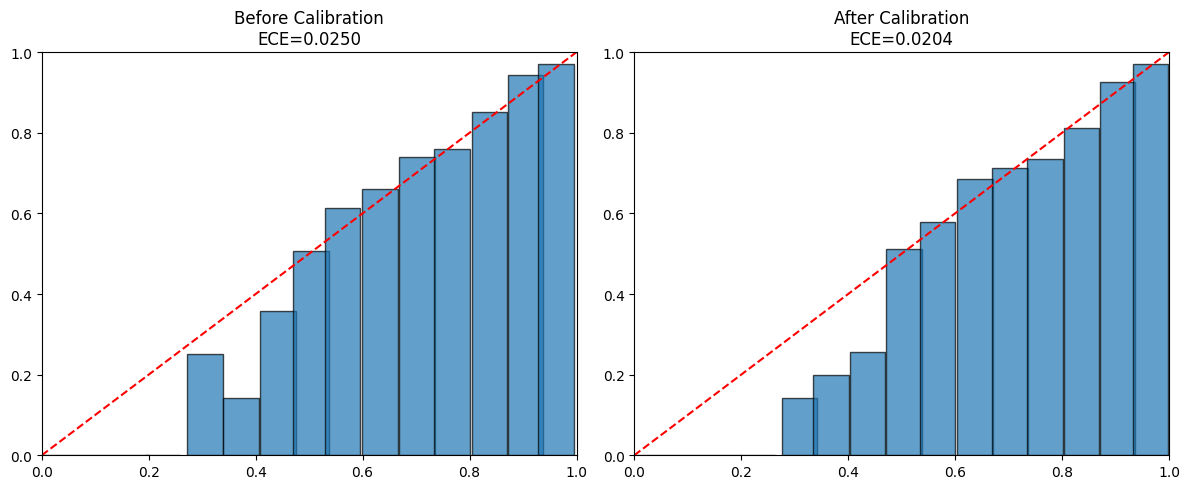

ECE: 0.0250 → 0.0204


In [ ]:
# ============================================================
# CELL 13 — TEMPERATURE CALIBRATION + ECE 
# ============================================================
print('='*70); print('TEMPERATURE CALIBRATION'); print('='*70)
val_results=validate(model,val_loader,criterion,device)
val_logits_cal=val_results['logits']; val_labels_cal=val_results['labels']

def nll_with_temperature(t,logits,labels):
    return -np.mean(scipy_log_softmax(logits/float(t),axis=1)[np.arange(len(labels)),labels])

result=minimize_scalar(nll_with_temperature,bounds=(0.3,5.0),args=(val_logits_cal,val_labels_cal),method='bounded')
optimal_temp=result.x
print(f'Optimal temperature: {optimal_temp:.4f}')
calibrated_probs=F.softmax(torch.tensor(test_logits/optimal_temp),dim=1).numpy()
cal_preds=np.argmax(calibrated_probs,axis=1)
cal_f1=f1_score(test_labels,cal_preds,average='macro',zero_division=0)
cal_bal=balanced_accuracy_score(test_labels,cal_preds)
print(f'Calibrated test: F1={cal_f1:.4f} | Bal={cal_bal:.4f}')

def compute_ece_and_plot(probs,labels,n_bins=15,title='',ax=None):
    conf=probs.max(axis=1); correct=(probs.argmax(axis=1)==labels).astype(float)
    edges=np.linspace(0,1,n_bins+1); ba,bc,bct=[],[],[]
    for i in range(n_bins):
        mask=(conf>=edges[i])&(conf<edges[i+1])
        ba.append(correct[mask].mean() if mask.sum()>0 else 0.0)
        bc.append(conf[mask].mean() if mask.sum()>0 else (edges[i]+edges[i+1])/2)
        bct.append(mask.sum())
    ba,bc,bct=map(np.array,[ba,bc,bct])
    ece=(bct*np.abs(ba-bc)).sum()/len(labels)
    if ax is None: _,ax=plt.subplots(figsize=(5,5))
    ax.bar(bc,ba,width=1/n_bins,alpha=0.7,edgecolor='black')
    ax.plot([0,1],[0,1],'r--'); ax.set_title(f'{title}\nECE={ece:.4f}')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    return ece

fig,axes=plt.subplots(1,2,figsize=(12,5))
ece_before=compute_ece_and_plot(test_probs,test_labels,title='Before Calibration',ax=axes[0])
ece_after =compute_ece_and_plot(calibrated_probs,test_labels,title='After Calibration',ax=axes[1])
plt.tight_layout(); plt.savefig('v15_calibration.png',dpi=120,bbox_inches='tight'); plt.show()
print(f'ECE: {ece_before:.4f} → {ece_after:.4f}')


In [ ]:
# ============================================================
# CELL 14 — THREE-TIER THRESHOLD SYSTEM 
# ============================================================
print('='*70); print('THREE-TIER THRESHOLD TUNING'); print('='*70)
val_cal_probs=F.softmax(torch.tensor(val_logits_cal/optimal_temp),dim=1).numpy()

def find_thresh(probs,labels,cls,name,min_ratio=0.95):
    results=[]
    for t in np.arange(0.03,0.86,0.01):
        pds=np.argmax(probs,axis=1).copy(); pds[probs[:,cls]>=t]=cls
        mk=labels==cls; rcl=np.mean(pds[mk]==cls) if mk.sum()>0 else 0.0
        results.append({'t':t,'rcl':rcl,'f1':f1_score(labels,pds,average='macro',zero_division=0)})
    df_r=pd.DataFrame(results); viable=df_r[df_r['f1']>=df_r['f1'].max()*min_ratio]
    if len(viable)==0: viable=df_r
    best=viable.loc[viable['rcl'].idxmax()]
    warn=' ← BELOW SAFE APP FLOOR' if best['t']<0.10 else ''
    print(f'  {name:25s}: thresh={best["t"]:.2f} | recall={best["rcl"]:.4f} | F1={best["f1"]:.4f}{warn}')
    return float(best['t'])

mel_t=find_thresh(val_cal_probs,val_labels_cal,1,'Melanoma')
bcc_t=find_thresh(val_cal_probs,val_labels_cal,3,'BCC')
ak_t =find_thresh(val_cal_probs,val_labels_cal,4,'Actinic keratoses')
thresholds={1:mel_t,3:bcc_t,4:ak_t}

def classify_three_tier(probs,thresholds):
    preds=np.argmax(probs,axis=1).copy(); tiers=np.zeros(len(preds),dtype=int)
    for i in range(len(preds)):
        cp=float(probs[i,CANCER_IDX].sum()); bc,bp=None,0.0
        for cls,thr in thresholds.items():
            if probs[i,cls]>=thr and probs[i,cls]>bp: bc,bp=cls,probs[i,cls]
        if bc is not None: preds[i]=bc
        if cp>=0.50 or (preds[i] in CANCER_IDX and probs[i,preds[i]]>=0.30): tiers[i]=2
        elif cp>=0.20 or preds[i] in CANCER_IDX: tiers[i]=1
    return preds,tiers

tier_preds,tier_labels_out=classify_three_tier(calibrated_probs,thresholds)
TIER_NAMES=['Likely Benign','Uncertain','Suspicious']
cancer_mask=np.isin(test_labels,CANCER_IDX)
print('\nTier distribution:')
for t in range(3):
    mask=tier_labels_out==t
    print(f'  {TIER_NAMES[t]:15s}: {mask.sum():5d} | {cancer_mask[mask].sum()} cancers')
flagged=tier_labels_out>=1; caught_3tier=(flagged&cancer_mask).sum()
print(f'\n3-Tier catch: {caught_3tier}/{cancer_mask.sum()} ({100*caught_3tier/cancer_mask.sum():.1f}%)')


THREE-TIER THRESHOLD TUNING
  Melanoma                 : thresh=0.07 | recall=0.8362 | F1=0.7604 ← BELOW SAFE APP FLOOR
  BCC                      : thresh=0.03 | recall=0.9038 | F1=0.7652 ← BELOW SAFE APP FLOOR
  Actinic keratoses        : thresh=0.06 | recall=1.0000 | F1=0.7633 ← BELOW SAFE APP FLOOR

Tier distribution:
  Likely Benign  :  1121 | 16 cancers
  Uncertain      :   378 | 54 cancers
  Suspicious     :   525 | 323 cancers

3-Tier catch: 377/393 (95.9%)


CLINICAL DOMAIN EVALUATION


Clinical-domain (Derm7pt held-out, N=247):
  Macro F1  : 0.5532
  Bal Acc   : 0.5519
  Binary AUC: 0.8353

Domain comparison:
  Dermoscopic F1 : 0.7964
  Clinical F1    : 0.5532
  Domain gap     : +0.2433 ← gap > 10pt — target is <10pt


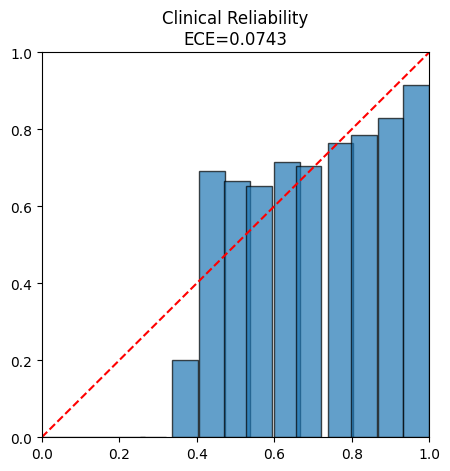

  Clinical ECE: 0.0743


In [ ]:
# ============================================================
# CELL 15 — CLINICAL DOMAIN EVALUATION 
# ============================================================
print('='*70); print('CLINICAL DOMAIN EVALUATION'); print('='*70)
clin_f1_cal=gap_estimate=ece_clin=clin_bal_cal=None
if clin_val_loader and len(clin_val_loader)>0:
    cr=validate(model,clin_val_loader,criterion,device)
    cp=F.softmax(torch.tensor(cr['logits']/optimal_temp),dim=1).numpy()
    cl=cr['labels']
    clin_f1_cal=f1_score(cl,np.argmax(cp,axis=1),average='macro',zero_division=0)
    clin_bal_cal=balanced_accuracy_score(cl,np.argmax(cp,axis=1))
    print(f'Clinical-domain (Derm7pt held-out, N={len(cl)}):')
    print(f'  Macro F1  : {clin_f1_cal:.4f}'); print(f'  Bal Acc   : {clin_bal_cal:.4f}')
    cm_=np.isin(cl,CANCER_IDX)
    if cm_.sum()>0:
        try: print(f'  Binary AUC: {roc_auc_score(cm_.astype(int),cp[:,CANCER_IDX].sum(axis=1)):.4f}')
        except: pass
    gap_estimate=cal_f1-clin_f1_cal
    print(f'\nDomain comparison:')
    print(f'  Dermoscopic F1 : {cal_f1:.4f}')
    print(f'  Clinical F1    : {clin_f1_cal:.4f}')
    print(f'  Domain gap     : {gap_estimate:+.4f}',end='')
    if gap_estimate>0.10: print(' ← gap > 10pt — target is <10pt')
    else: print(' ← within target range')
    ece_clin=compute_ece_and_plot(cp,cl,title='Clinical Reliability')
    plt.savefig('v15_clinical_calibration.png',dpi=120,bbox_inches='tight'); plt.show()
    print(f'  Clinical ECE: {ece_clin:.4f}')
else:
    print('No clinical-val loader. Check Derm7pt path.')


FINAL RESULTS COMPARISON
Metric                           Argmax   Calibrated     Thresholds
-----------------------------------------------------------------
Bal Acc                          0.8153       0.8153         0.7767
Macro F1                         0.7964       0.7964         0.7115
Melanoma Recall                  0.5975       0.5975         0.9025
Basal Recall                     0.8111       0.8111         0.8778
Actinic Recall                   0.8955       0.8955         0.9552

Cancer Catch:
  Argmax    : 290/393 (73.8%)
  Thresholds: 377/393 (95.9%)
  3-Tier Ref: 377/393 (95.9%)

CROSS-DOMAIN PERFORMANCE
Domain                       F1    Bal Acc        ECE
-------------------------------------------------------
Dermoscopic (HAM)        0.7964     0.8153     0.0204
Clinical (Derm7pt)       0.5532     0.5519     0.0743

Domain gap: 24.3pt (target <10pt)

                      precision    recall  f1-score   support

    Melanocytic nevi     0.9699    0.6999    0.8130  

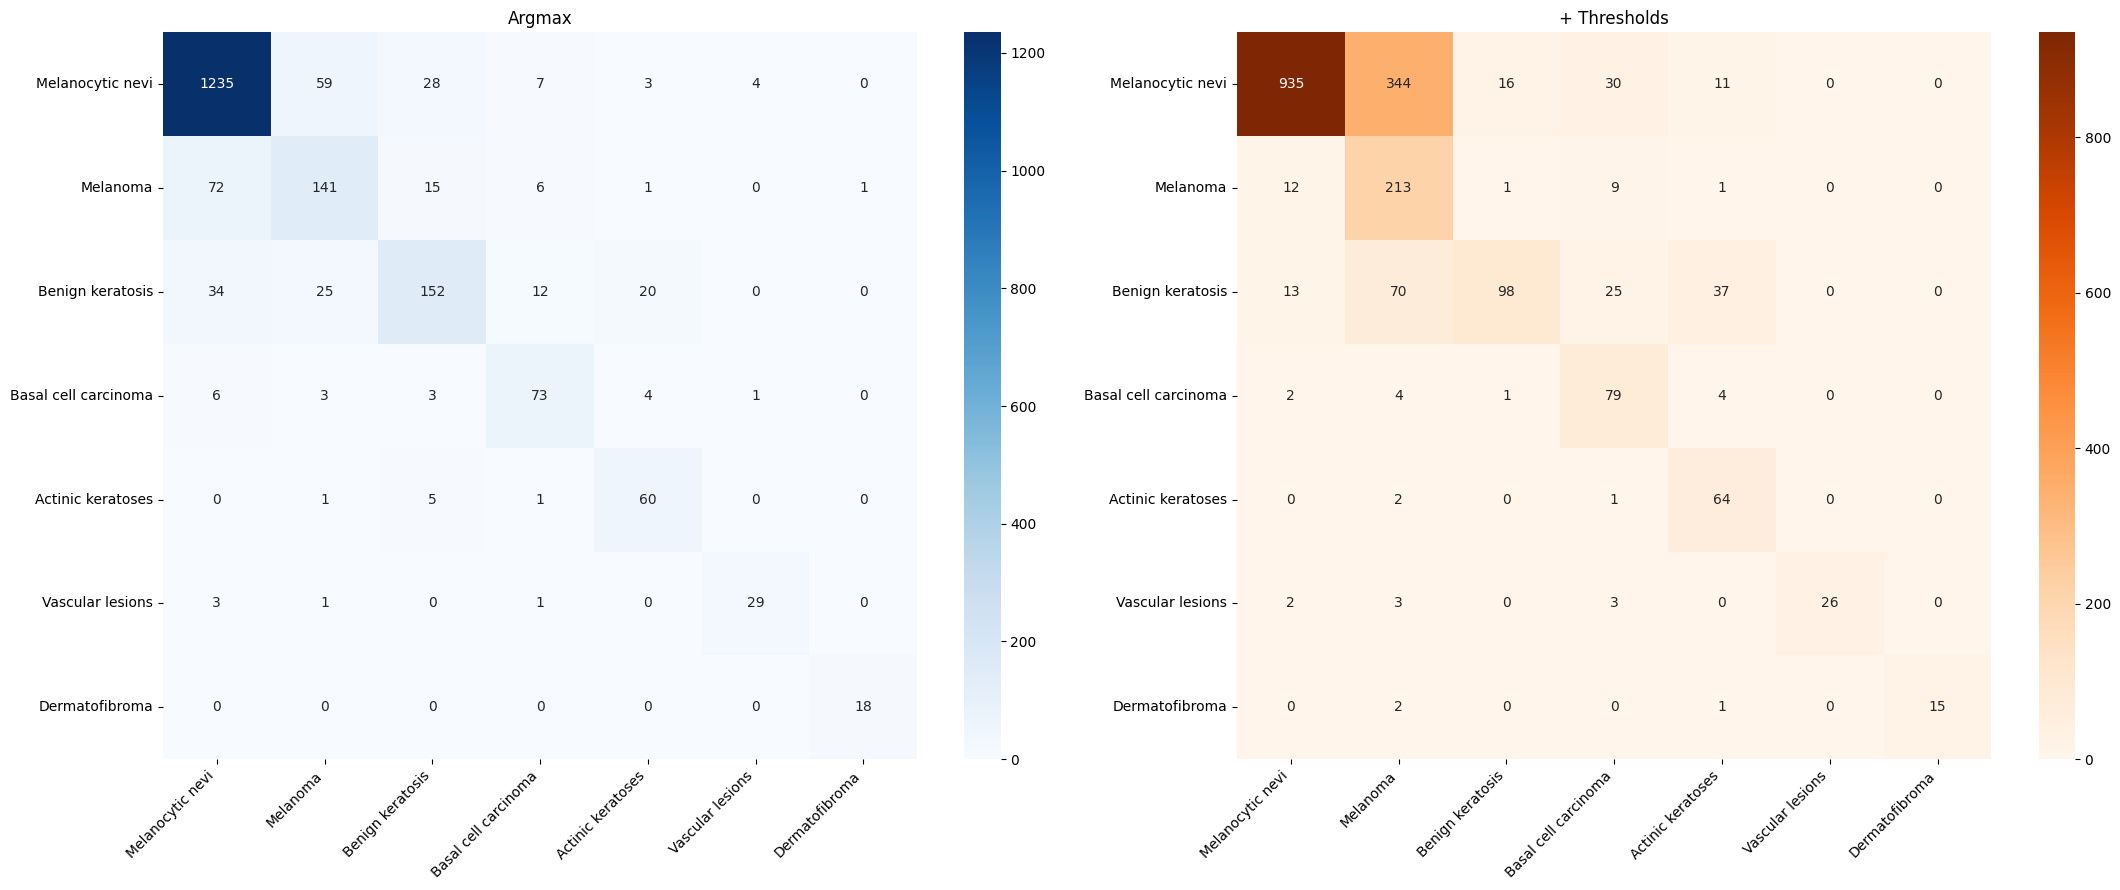

In [16]:
# ============================================================
# CELL 16 — FINAL RESULTS COMPARISON + CONFUSION MATRICES
# ============================================================
print('='*70); print('FINAL RESULTS COMPARISON'); print('='*70)
tier_bal=balanced_accuracy_score(test_labels,tier_preds)
tier_f1=f1_score(test_labels,tier_preds,average='macro',zero_division=0)
tier_pcr=recall_score(test_labels,tier_preds,average=None,labels=list(range(NUM_CLASSES)),zero_division=0)
cal_pcr=recall_score(test_labels,cal_preds,average=None,labels=list(range(NUM_CLASSES)),zero_division=0)
print(f"{'Metric':<28} {'Argmax':>10} {'Calibrated':>12} {'Thresholds':>14}")
print('-'*65)
print(f"{'Bal Acc':<28} {bal_acc:>10.4f} {cal_bal:>12.4f} {tier_bal:>14.4f}")
print(f"{'Macro F1':<28} {macro_f1:>10.4f} {cal_f1:>12.4f} {tier_f1:>14.4f}")
for i in CANCER_IDX:
    nm=CLASS_NAMES[i].split()[0]+' Recall'
    print(f"{nm:<28} {pcr[i]:>10.4f} {cal_pcr[i]:>12.4f} {tier_pcr[i]:>14.4f}")
cancer_mask=np.isin(test_labels,CANCER_IDX)
ca=cancer_mask.sum()-np.isin(test_preds[cancer_mask],BENIGN_IDX).sum()
ct=cancer_mask.sum()-np.isin(tier_preds[cancer_mask],BENIGN_IDX).sum()
cr_=(tier_labels_out>=1)&cancer_mask
print(f"\nCancer Catch:")
print(f"  Argmax    : {ca}/{cancer_mask.sum()} ({100*ca/cancer_mask.sum():.1f}%)")
print(f"  Thresholds: {ct}/{cancer_mask.sum()} ({100*ct/cancer_mask.sum():.1f}%)")
print(f"  3-Tier Ref: {cr_.sum()}/{cancer_mask.sum()} ({100*cr_.sum()/cancer_mask.sum():.1f}%)")
print(f"\n{'='*65}\nCROSS-DOMAIN PERFORMANCE\n{'='*65}")
print(f"{'Domain':<20} {'F1':>10} {'Bal Acc':>10} {'ECE':>10}")
print('-'*55)
print(f"{'Dermoscopic (HAM)':<20} {cal_f1:>10.4f} {cal_bal:>10.4f} {ece_after:>10.4f}")
if clin_f1_cal:
    print(f"{'Clinical (Derm7pt)':<20} {clin_f1_cal:>10.4f} {clin_bal_cal:>10.4f} {ece_clin:>10.4f}")
    print(f"\nDomain gap: {(cal_f1-clin_f1_cal)*100:.1f}pt (target <10pt)")
print(f'\n{classification_report(test_labels,tier_preds,target_names=CLASS_NAMES,digits=4)}')
fig,axes=plt.subplots(1,2,figsize=(22,9))
sns.heatmap(confusion_matrix(test_labels,test_preds),annot=True,fmt='d',cmap='Blues',
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=axes[0])
axes[0].set_title('Argmax'); axes[0].set_xticklabels(CLASS_NAMES,rotation=45,ha='right')
sns.heatmap(confusion_matrix(test_labels,tier_preds),annot=True,fmt='d',cmap='Oranges',
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=axes[1])
axes[1].set_title('+ Thresholds'); axes[1].set_xticklabels(CLASS_NAMES,rotation=45,ha='right')
plt.tight_layout(); plt.savefig('v15_confusion_matrices.png',dpi=120,bbox_inches='tight'); plt.show()


In [ ]:
# ============================================================
# CELL 17 — SINGLE-IMAGE INFERENCE 
# ============================================================
def predict_single(model,pil_image,age=None,sex=None,location=None,
                   temperature=1.0,thresholds=None,top_k=3,device=device):
    model.eval()
    if thresholds is None: thresholds={}
    with torch.no_grad():
        probs_np=F.softmax(model(preprocess_for_inference(pil_image).to(device),
                                  encode_app_metadata(age,sex,location).to(device))/float(temperature),dim=1).cpu().numpy()[0]
    tp,tl=classify_three_tier(probs_np[None,:],thresholds)
    pc,tier=int(tp[0]),int(tl[0])
    entropy=-float(np.sum(probs_np*np.log(probs_np+1e-9)))
    return {
        'top_k':[(CLASS_NAMES[i],float(probs_np[i])) for i in np.argsort(probs_np)[::-1][:top_k]],
        'probabilities':probs_np,'cancer_prob':float(probs_np[CANCER_IDX].sum()),
        'tier':tier,'tier_name':TIER_NAMES[tier],'predicted_class':CLASS_NAMES[pc],
        'confidence':float(probs_np[pc]),'high_entropy':entropy>0.7*np.log(NUM_CLASSES),'entropy':entropy,
    }

_row=ham_test.df.iloc[0]; _p=None
for _d in IMAGE_DIRS:
    _pp=os.path.join(_d,f"{_row['image_id']}.jpg")
    if os.path.exists(_pp): _p=_pp; break
if _p:
    _r=predict_single(model,Image.open(_p).convert('RGB'),age=_row.get('age'),
                      sex=_row.get('sex'),location=_row.get('localization'),
                      temperature=optimal_temp,thresholds=thresholds)
    print('predict_single output:')
    for k,v in _r.items():
        if k!='probabilities': print(f'  {k:20s}: {v}')
    print(f'  Ground truth         : {CLASS_NAMES[LABEL_MAP[_row["dx"]]]}')


predict_single output:
  top_k               : [('Benign keratosis', 0.9559715390205383), ('Basal cell carcinoma', 0.023083141073584557), ('Melanocytic nevi', 0.01410613488405943)]
  cancer_prob         : 0.0262130293995142
  tier                : 0
  tier_name           : Likely Benign
  predicted_class     : Benign keratosis
  confidence          : 0.9559715390205383
  high_entropy        : False
  entropy             : 0.23114828765392303
  Ground truth         : Benign keratosis


In [ ]:
# ============================================================
# CELL 18 — PYTORCH MOBILE EXPORT
# ============================================================
from torch.utils.mobile_optimizer import optimize_for_mobile

class MobileWrapperV15(nn.Module):
    def __init__(self,model,temperature):
        super().__init__(); self.model=model; self.temperature=float(temperature)
    def forward(self,image,metadata):
        probs=torch.softmax(self.model(image,metadata)/self.temperature,dim=1)
        return probs, probs[:,[1,3,4]].sum(dim=1,keepdim=True)

model.eval(); mm=MobileWrapperV15(model,optimal_temp); mm.eval().cpu()
di=torch.randn(1,3,IMG_SIZE,IMG_SIZE); dm=encode_app_metadata(50,'female','back')
with torch.no_grad(): _p,_c=mm(di,dm)
assert _p.shape==(1,NUM_CLASSES) and abs(_p.sum().item()-1.0)<1e-5
print(f'Output contract verified: probs={_p.shape}, cancer_prob={_c.item():.4f}')
with torch.no_grad(): traced=torch.jit.trace(mm,(di,dm))
opt=optimize_for_mobile(traced); ptl_path='skin_cancer_v15.ptl'
opt._save_for_lite_interpreter(ptl_path)
size_mb=os.path.getsize(ptl_path)/1024/1024
pl=torch.jit.load(ptl_path)
with torch.no_grad(): pp,_=pl(di,dm)
max_diff=(_p-pp).abs().max().item()
assert max_diff<1e-4; print(f'PTL: {ptl_path} ({size_mb:.1f} MB), diff={max_diff:.2e}')
model.to(device)

APP_FLOORS={'1':0.35,'3':0.25,'4':0.15}
app_safe={k:max(float(thresholds[int(k)]),float(v)) for k,v in APP_FLOORS.items()}

v15_meta={
    'version':'v15','model_name':MODEL_NAME,'img_size':IMG_SIZE,'num_classes':NUM_CLASSES,
    'class_names':CLASS_NAMES,'cancer_indices':CANCER_IDX,'benign_indices':BENIGN_IDX,
    'temperature':float(optimal_temp),'temperature_applied_in_model':True,'output_is_probs':True,
    'optimal_thresholds':{str(k):float(v) for k,v in thresholds.items()},
    'app_safe_thresholds':app_safe,'app_threshold_floors':APP_FLOORS,
    'tier_thresholds':{'suspicious':0.50,'uncertain':0.20},'tier_names':TIER_NAMES,
    'metadata_dim':METADATA_DIM,'metadata_layout':'age(1)|sex_onehot(3)|loc_onehot(15)|domain_onehot(2)',
    'sex_map':SEX_MAP,'location_map':LOC_MAP,'domain_map':DOMAIN_MAP,'default_domain':'clinical',
    'preprocessing':PREPROCESS_SPEC,
    'entropy_threshold':0.7*float(np.log(NUM_CLASSES)),'max_entropy':float(np.log(NUM_CLASSES)),
    'argmax_bal_acc':float(bal_acc),'argmax_macro_f1':float(macro_f1),
    'calibrated_macro_f1':float(cal_f1),'tier_macro_f1':float(tier_f1),
    'binary_auc':float(binary_auc),'ece_before':float(ece_before),'ece_after':float(ece_after),
    'clinical_f1':float(clin_f1_cal) if clin_f1_cal else None,
    'domain_gap':float(gap_estimate) if gap_estimate else None,
    'training_datasets':['HAM10000','ISIC2019','Derm7pt','Fitzpatrick17k','Dermnet','AugmentedAK+DF','PAD-UFES-20'],
    'v15_changes':['EPOCHS_S1=20','CLINICAL_DOMAIN_BOOST=2.0','Balanced cancer composite MEL/BCC/AK',
                   'Derm7pt StratifiedShuffleSplit val_fraction=0.25','AugmentedMinorityDataset added',
                   'PADUFES20Dataset added','Stage1 unlocks conv_head','All 3 cancer recalls logged'],
}
with open('v15_metadata.json','w') as f: json.dump(v15_meta,f,indent=2)
torch.save({'model_state_dict':model.state_dict(),'temperature':optimal_temp,
            'thresholds':thresholds,'metadata':v15_meta},'skin_cancer_v15_final.pth')

print('\n'+'='*70); print('V15 EXPORT COMPLETE'); print('='*70)
print(f'  PTL          : {ptl_path} ({size_mb:.1f} MB)')
print(f'  Metadata     : v15_metadata.json')
print(f'  Checkpoint   : skin_cancer_v15_final.pth')
print(f'  Temperature  : {optimal_temp:.4f}')
print(f'  ECE          : {ece_before:.4f} → {ece_after:.4f}')
print(f'  Binary AUC   : {binary_auc:.4f}')
print(f'  3-Tier catch : {100*caught_3tier/cancer_mask.sum():.1f}%')
if gap_estimate: print(f'  Domain gap   : {gap_estimate:+.4f} (target <10pt)')


Output contract verified: probs=torch.Size([1, 7]), cancer_prob=0.6424
PTL: skin_cancer_v15.ptl (29.9 MB), diff=6.56e-07

V15 EXPORT COMPLETE
  PTL          : skin_cancer_v15.ptl (29.9 MB)
  Metadata     : v15_metadata.json
  Checkpoint   : skin_cancer_v15_final.pth
  Temperature  : 0.9427
  ECE          : 0.0250 → 0.0204
  Binary AUC   : 0.9270
  3-Tier catch : 95.9%
  Domain gap   : +0.2433 (target <10pt)
